In [ ]:
import pandas as pd
import missingno as msno
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
from xgboost import XGBClassifier
from sklearn.inspection import permutation_importance
import shap
import lightgbm as lgb
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
import joblib


# Datos del ejercicio

El banco portugués está teniendo una disminución en sus ingresos, por lo que quieren poder identificar a los clientes existentes que tienen una mayor probabilidad de contratar un depósito a largo plazo. Esto permitirá que el banco centre sus esfuerzos de marketing en esos clientes y evitará perder dinero y tiempo en clientes que probablemente no se suscribirán.

Para abordar este problema crearemos un algoritmo de clasificación que ayude a predecir si un cliente contratará o no un depósito a largo plazo. \
1 age. Edad del cliente (numérico) \
2 job. Tipo de trabajo (categórico) \
3 marital. Estado civil (categórico) \
4 education. Nivel de educación (categórico) \
5 default. ¿Tiene crédito actualmente? (categórico) \
6 housing. ¿Tiene un préstamo de vivienda? (categórico) \
7 loan. ¿Tiene un préstamo personal? (categórico) \
8 contact. Tipo de comunicación de contacto (categórico) \
9 month. Último mes en el que se le ha contactado (categórico) \
10 day_of_week. Último día en el que se le ha contactado (categórico) \
11 duration. Duración del contacto previo en segundos (numérico) \
12 campaign. Número de contactos realizados durante esta campaña al cliente (numérico) \
13 pdays. Número de días que transcurrieron desde la última campaña hasta que fue contactado (numérico) \
14 previous. Número de contactos realizados durante la campaña anterior al cliente (numérico) \
15 poutcome. Resultado de la campaña de marketing anterior (categórico) \
16 emp.var.rate. Tasa de variación del empleo. Indicador trimestral (numérico) \
17 cons.price.idx. Índice de precios al consumidor. Indicador mensual (numérico) \
18 cons.conf.idx. Índice de confianza del consumidor. Indicador mensual (numérico) \
19 euribor3m. Tasa EURIBOR 3 meses. Indicador diario (numérico) \
20 nr.employed. Número de empleados. Indicador trimestral (numérico) \
21 y. TARGET. El cliente contrata un depósito a largo plazo o no (categórico) 

In [309]:
df=pd.read_csv("/workspaces/jovegom-intro-ml/data/bank-marketing-campaign-data.csv",sep=';')

In [310]:
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.100,93.994,-36.400,4.857,5191.000,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.100,93.994,-36.400,4.857,5191.000,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.100,93.994,-36.400,4.857,5191.000,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.100,93.994,-36.400,4.857,5191.000,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.100,93.994,-36.400,4.857,5191.000,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.100,94.767,-50.800,1.028,4963.600,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.100,94.767,-50.800,1.028,4963.600,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.100,94.767,-50.800,1.028,4963.600,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.100,94.767,-50.800,1.028,4963.600,yes


# EDA

## Identificamos valores unicos

In [311]:
valores_unicos=df.nunique()
valores_unicos

age                 78
job                 12
marital              4
education            8
default              3
housing              3
loan                 3
contact              2
month               10
day_of_week          5
duration          1544
campaign            42
pdays               27
previous             8
poutcome             3
emp.var.rate        10
cons.price.idx      26
cons.conf.idx       26
euribor3m          316
nr.employed         11
y                    2
dtype: int64

No tenemos valores unicos

## Filas y columnas duplicadas

In [312]:
# Filas duplicadas
df.duplicated().sum()

np.int64(12)

In [313]:
# Tenemos 12 duplicados los cuales eliminamos
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [314]:
df.T.duplicated().sum()

np.int64(0)

No tenemos columnas duplicadas

## Valores Faltantes

In [315]:
promedio_faltantes=df.isna().mean()*100
faltantes = ["no hay valores faltantes"] if any(n == 0 for n in promedio_faltantes) else promedio_faltantes
faltantes


['no hay valores faltantes']

### Valores faltantes enmascarados   

In [316]:
# traemos el Df con solo columnas categoricas
df_cate = df.select_dtypes(include=['object'])
# sacamos la cantidad de unknown por columna
unknown_counts = df_cate.apply(lambda col: (col == "unknown").sum())
# sacamos el porcentaje de unknown
unknown_porce= df_cate.apply(lambda col: (col == "unknown").mean()*100)
# creamos un DF con esta info
df_result=pd.DataFrame({'unknown_counts':unknown_counts,'unknown_porcentaje':unknown_porce}).sort_values(by='unknown_counts',ascending=False)
df_result

,unknown_counts,unknown_porcentaje
default,8596,20.876
education,1730,4.201
housing,990,2.404
loan,990,2.404
job,330,0.801
marital,80,0.194
contact,0,0.000
month,0,0.000
day_of_week,0,0.000
poutcome,0,0.000


deacuerdo a lo anterior se decide eliminar los datos que tienen menos del 1% y se pone en consideracion mas adelante los que tienen un 2.4%

In [317]:
df_cate = df.select_dtypes(include=['object'])
# sacamos la cantidad de unknown por columna
nonexistent_counts = df_cate.apply(lambda col: (col == "nonexistent").sum())
# sacamos el porcentaje de unknown
nonexistent_porce= df_cate.apply(lambda col: (col == "nonexistent").mean()*100)
# creamos un DF con esta info
df_result=pd.DataFrame({'nonexistent_counts':nonexistent_counts,'nonexistent_porcentaje':nonexistent_porce}).sort_values(by='nonexistent_counts',ascending=False)
df_result

,nonexistent_counts,nonexistent_porcentaje
poutcome,35551,86.339
marital,0,0.000
job,0,0.000
education,0,0.000
default,0,0.000
loan,0,0.000
housing,0,0.000
contact,0,0.000
month,0,0.000
day_of_week,0,0.000


Eliminamos la columna poutcome, ya que en su mayoria no posee datos que nos aporte al modelo

In [318]:
df = df.drop('poutcome', axis=1)

In [319]:
df=df[df['job']!='unknown']
df=df[df['marital']!='unknown']
unknown_counts = df[['job','marital']].apply(lambda col: (col == "unknown").sum())
unknown_counts

job        0
marital    0
dtype: int64

<Axes: >

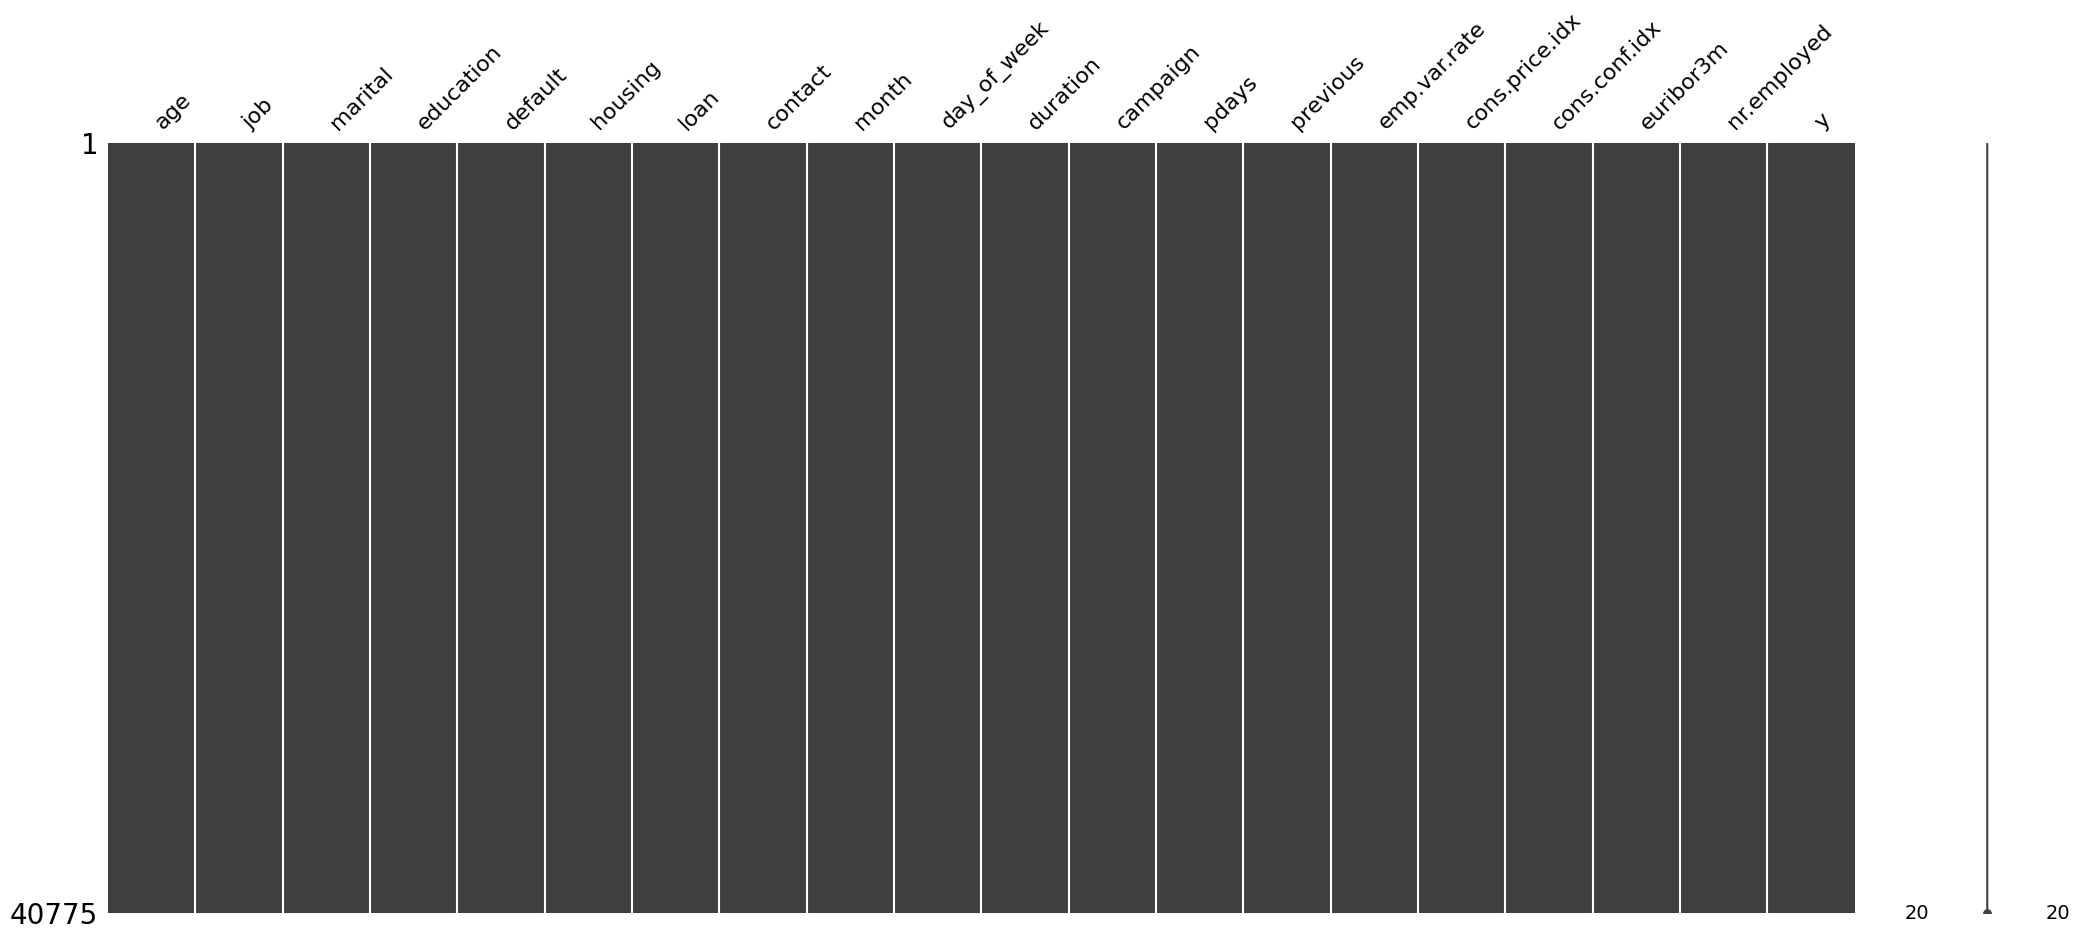

In [320]:
msno.matrix(df)

## Tranin test split

In [321]:
le = LabelEncoder()
y = le.fit_transform(df['y'])
X= df.drop('y',axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Codificacion de variables

In [322]:
def encode_categoricals(X_train, X_test):
    """
    Codifica variables categóricas:
    - One-hot para columnas con <=4 categorías
    - Frequency encoding para columnas con >4 categorías
    Devuelve X_train_final, X_test_final
    """
    import pandas as pd

    # Separar columnas categóricas y numéricas
    cat_cols = X_train.select_dtypes(include=['object']).columns
    num_cols = X_train.select_dtypes(exclude=['object']).columns

    # Dividir según cardinalidad
    num_categories = X_train[cat_cols].nunique()
    onehot_cols = num_categories[num_categories <= 4].index.tolist()
    freq_cols   = num_categories[num_categories > 4].index.tolist()

    # -----------------------------
    # One-Hot Encoding
    # -----------------------------
    X_train_oh = pd.get_dummies(X_train[onehot_cols], drop_first=True, dtype=int)
    X_test_oh  = pd.get_dummies(X_test[onehot_cols], drop_first=True, dtype=int)
    X_test_oh = X_test_oh.reindex(columns=X_train_oh.columns, fill_value=0)

    # -----------------------------
    # Frequency Encoding
    # -----------------------------
    X_train_freq = X_train[freq_cols].copy()
    X_test_freq  = X_test[freq_cols].copy()
    freq_maps = {}
    for col in freq_cols:
        freq = X_train[col].value_counts(normalize=True)
        freq_maps[col] = freq
        X_train_freq[col] = X_train[col].map(freq)
        X_test_freq[col] = X_test[col].map(freq).fillna(0)

    # -----------------------------
    # Combinar con columnas numéricas
    # -----------------------------
    X_train_final = pd.concat(
        [X_train[num_cols].reset_index(drop=True),
         X_train_oh.reset_index(drop=True),
         X_train_freq.reset_index(drop=True)],
        axis=1
    )

    X_test_final = pd.concat(
        [X_test[num_cols].reset_index(drop=True),
         X_test_oh.reset_index(drop=True),
         X_test_freq.reset_index(drop=True)],
        axis=1
    )

    return X_train_final, X_test_final

In [323]:
X_train_final, X_test_final = encode_categoricals(X_train, X_test)

## Outliers

In [324]:
pd.set_option('display.float_format', '{:.3f}'.format)
X_train_final.describe().T

,count,mean,std,min,25%,50%,75%,max
age,32620.000,39.972,10.382,17.000,32.000,38.000,47.000,98.000
duration,32620.000,258.068,258.170,0.000,102.000,179.000,320.000,3785.000
campaign,32620.000,2.576,2.763,1.000,1.000,2.000,3.000,56.000
pdays,32620.000,962.808,186.086,0.000,999.000,999.000,999.000,999.000
previous,32620.000,0.171,0.489,0.000,0.000,0.000,0.000,6.000
emp.var.rate,32620.000,0.084,1.570,-3.400,-1.800,1.100,1.400,1.400
cons.price.idx,32620.000,93.576,0.578,92.201,93.075,93.749,93.994,94.767
cons.conf.idx,32620.000,-40.526,4.625,-50.800,-42.700,-41.800,-36.400,-26.900
euribor3m,32620.000,3.622,1.734,0.634,1.344,4.857,4.961,5.045
nr.employed,32620.000,5167.191,72.170,4963.600,5099.100,5191.000,5228.100,5228.100


In [325]:
iso = IsolationForest(random_state=123)
df_num = X_train_final.copy()
df_num['outlier_flag'] = iso.fit_predict(X_train_final)
df_num['outlier_flag'].value_counts()

outlier_flag
 1    22666
-1     9954
Name: count, dtype: int64

### Tratamos los Outliers
aplicamos Clipping y escalamos datos

In [326]:
num_cols = X_train_final.select_dtypes(include=['float64', 'int64']).columns.tolist()

# Aplicar Clipping para outliers

# Limites por percentiles 10% y 90%
for col in num_cols:
    lower = X_train_final[col].quantile(0.1)
    upper = X_train_final[col].quantile(0.9)
    
    X_train_final[col] = X_train_final[col].clip(lower=lower, upper=upper)
    X_test_final[col]  = X_test_final[col].clip(lower=lower, upper=upper)  # usar mismo límite de train

# Escalar columnas numéricas

scaler = StandardScaler()
X_train_final[num_cols] = scaler.fit_transform(X_train_final[num_cols])
X_test_final[num_cols]  = scaler.transform(X_test_final[num_cols])

In [327]:
iso = IsolationForest(random_state=123)
df_num = X_train_final.copy()
df_num['outlier_flag'] = iso.fit_predict(X_train_final)
df_num['outlier_flag'].value_counts()

outlier_flag
-1    28906
 1     3714
Name: count, dtype: int64

## Seleccion de caracteristicas

### Método 1 Feature importance de RF

In [328]:
# Entrenamiento de RF
model = RandomForestClassifier(random_state=42,n_jobs=-1).fit(X_train_final, y_train)
# Importancia de características
importances = model.feature_importances_/model.feature_importances_.sum()*100
# Convertir a DataFrame
df_rf_imp = pd.DataFrame({'feature': X_train_final.columns,'rf_importance': importances}).sort_values(by='rf_importance', ascending=False)
# Calculamos la importancia acumulada
df_rf_imp['rf_importance_acum'] = df_rf_imp['rf_importance'].cumsum()
df_rf_imp

,feature,rf_importance,rf_importance_acum
1,duration,28.825,28.825
8,euribor3m,10.373,39.198
0,age,9.845,49.043
19,job,6.113,55.156
22,day_of_week,5.658,60.814
9,nr.employed,5.562,66.375
2,campaign,5.371,71.746
20,education,5.070,76.816
21,month,3.502,80.317
5,emp.var.rate,3.308,83.626


### Metodo 2 Permutation/Shuffle importance

In [329]:
# Para esta técnica y la de shap se necesita conjunto de validación
X_train1, X_val, y_train1, y_val = train_test_split(X_train_final, y_train, test_size=0.2, random_state=42)

# Ajustamos el modelo
model_xgb = XGBClassifier(objective='binary:logistic',random_state=42,use_label_encoder=False,eval_metric='logloss').fit(X_train1, y_train1)

# Realizamos 10 permutaciones por cada característica (se usa neg_mean_absolute_error)
perm = permutation_importance(model_xgb, X_val, y_val, n_repeats=10, random_state=42, n_jobs=-1, scoring='accuracy')

df_perm_imp = pd.DataFrame({'feature': X_train_final.columns, 'perm_imp': perm.importances_mean*100}).sort_values('perm_imp', ascending=False)
df_perm_imp

,feature,perm_imp
1,duration,4.971
8,euribor3m,3.190
5,emp.var.rate,2.049
9,nr.employed,1.039
21,month,0.785
18,contact_telephone,0.578
22,day_of_week,0.403
6,cons.price.idx,0.354
0,age,0.337
7,cons.conf.idx,0.284


### Metodo 3 SHAP

In [330]:
# Ajustamos el modelo
model_lgbm = lgb.LGBMClassifier(random_state=42, n_jobs=-1).fit(X_train_final, y_train)

explainer = shap.Explainer(model_lgbm, X_val)   # usa el mismo X_val
shap_vals = explainer(X_val).values

imp_shap = np.abs(shap_vals).mean(axis=0)
imp_shap_pct = imp_shap/imp_shap.sum()*100
df_shap_imp = pd.DataFrame({"feature": X_val.columns, "shap_imp": imp_shap_pct}).sort_values('shap_imp', ascending=False)
df_shap_imp

[LightGBM] [Info] Number of positive: 3651, number of negative: 28969
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002603 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 498
[LightGBM] [Info] Number of data points in the train set: 32620, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.111925 -> initscore=-2.071225
[LightGBM] [Info] Start training from score -2.071225


 97%|=================== | 6351/6524 [00:16<00:00]       

,feature,shap_imp
1,duration,38.815
5,emp.var.rate,21.476
8,euribor3m,8.625
21,month,8.403
9,nr.employed,5.942
18,contact_telephone,3.423
0,age,2.040
6,cons.price.idx,1.926
12,default_unknown,1.776
7,cons.conf.idx,1.395


### Union de metodos

In [331]:
df_importances = (
    df_rf_imp
    .merge(df_perm_imp, on='feature', how='outer')
    .merge(df_shap_imp, on='feature', how='outer')
).sort_values('rf_importance', ascending=False)
df_importances

,feature,rf_importance,rf_importance_acum,perm_imp,shap_imp
8,duration,28.825,28.825,4.971,38.815
11,euribor3m,10.373,39.198,3.190,8.625
0,age,9.845,49.043,0.337,2.040
14,job,6.113,55.156,0.156,1.256
5,day_of_week,5.658,60.814,0.403,1.246
20,nr.employed,5.562,66.375,1.039,5.942
1,campaign,5.371,71.746,0.129,1.376
9,education,5.070,76.816,0.112,0.919
19,month,3.502,80.317,0.785,8.403
10,emp.var.rate,3.308,83.626,2.049,21.476


### Caracteristicas pre-seleccionadas

In [332]:
df_filt = df_importances[(df_importances['rf_importance']>=2)|(df_importances['perm_imp']>=2)|(df_importances['shap_imp']>=2)]
df_filt

,feature,rf_importance,rf_importance_acum,perm_imp,shap_imp
8,duration,28.825,28.825,4.971,38.815
11,euribor3m,10.373,39.198,3.190,8.625
0,age,9.845,49.043,0.337,2.040
14,job,6.113,55.156,0.156,1.256
5,day_of_week,5.658,60.814,0.403,1.246
20,nr.employed,5.562,66.375,1.039,5.942
1,campaign,5.371,71.746,0.129,1.376
9,education,5.070,76.816,0.112,0.919
19,month,3.502,80.317,0.785,8.403
10,emp.var.rate,3.308,83.626,2.049,21.476


### VIF y correlacion

In [333]:
features = df_filt['feature']
features

8              duration
11            euribor3m
0                   age
14                  job
5           day_of_week
20          nr.employed
1              campaign
9             education
19                month
10         emp.var.rate
13          housing_yes
3        cons.price.idx
2         cons.conf.idx
4     contact_telephone
Name: feature, dtype: object

In [334]:
vif = pd.Series([variance_inflation_factor(X_train_final[features].corr().values, i) for i in range(X_train_final[features].corr().shape[1])], index=X_train_final[features].columns)
df_vif = pd.Series(vif, name='vif').reset_index().rename(columns={'index': 'feature'})
df_vif_filt=pd.merge(df_vif, df_filt, on='feature' ,how='inner')
df_vif_filt

,feature,vif,rf_importance,rf_importance_acum,perm_imp,shap_imp
0,duration,1.530,28.825,28.825,4.971,38.815
1,euribor3m,39722.445,10.373,39.198,3.190,8.625
2,age,1.399,9.845,49.043,0.337,2.040
3,job,1.397,6.113,55.156,0.156,1.256
4,day_of_week,1.102,5.658,60.814,0.403,1.246
5,nr.employed,59571.116,5.562,66.375,1.039,5.942
6,campaign,3.063,5.371,71.746,0.129,1.376
7,education,1.371,5.070,76.816,0.112,0.919
8,month,161.048,3.502,80.317,0.785,8.403
9,emp.var.rate,42678.363,3.308,83.626,2.049,21.476


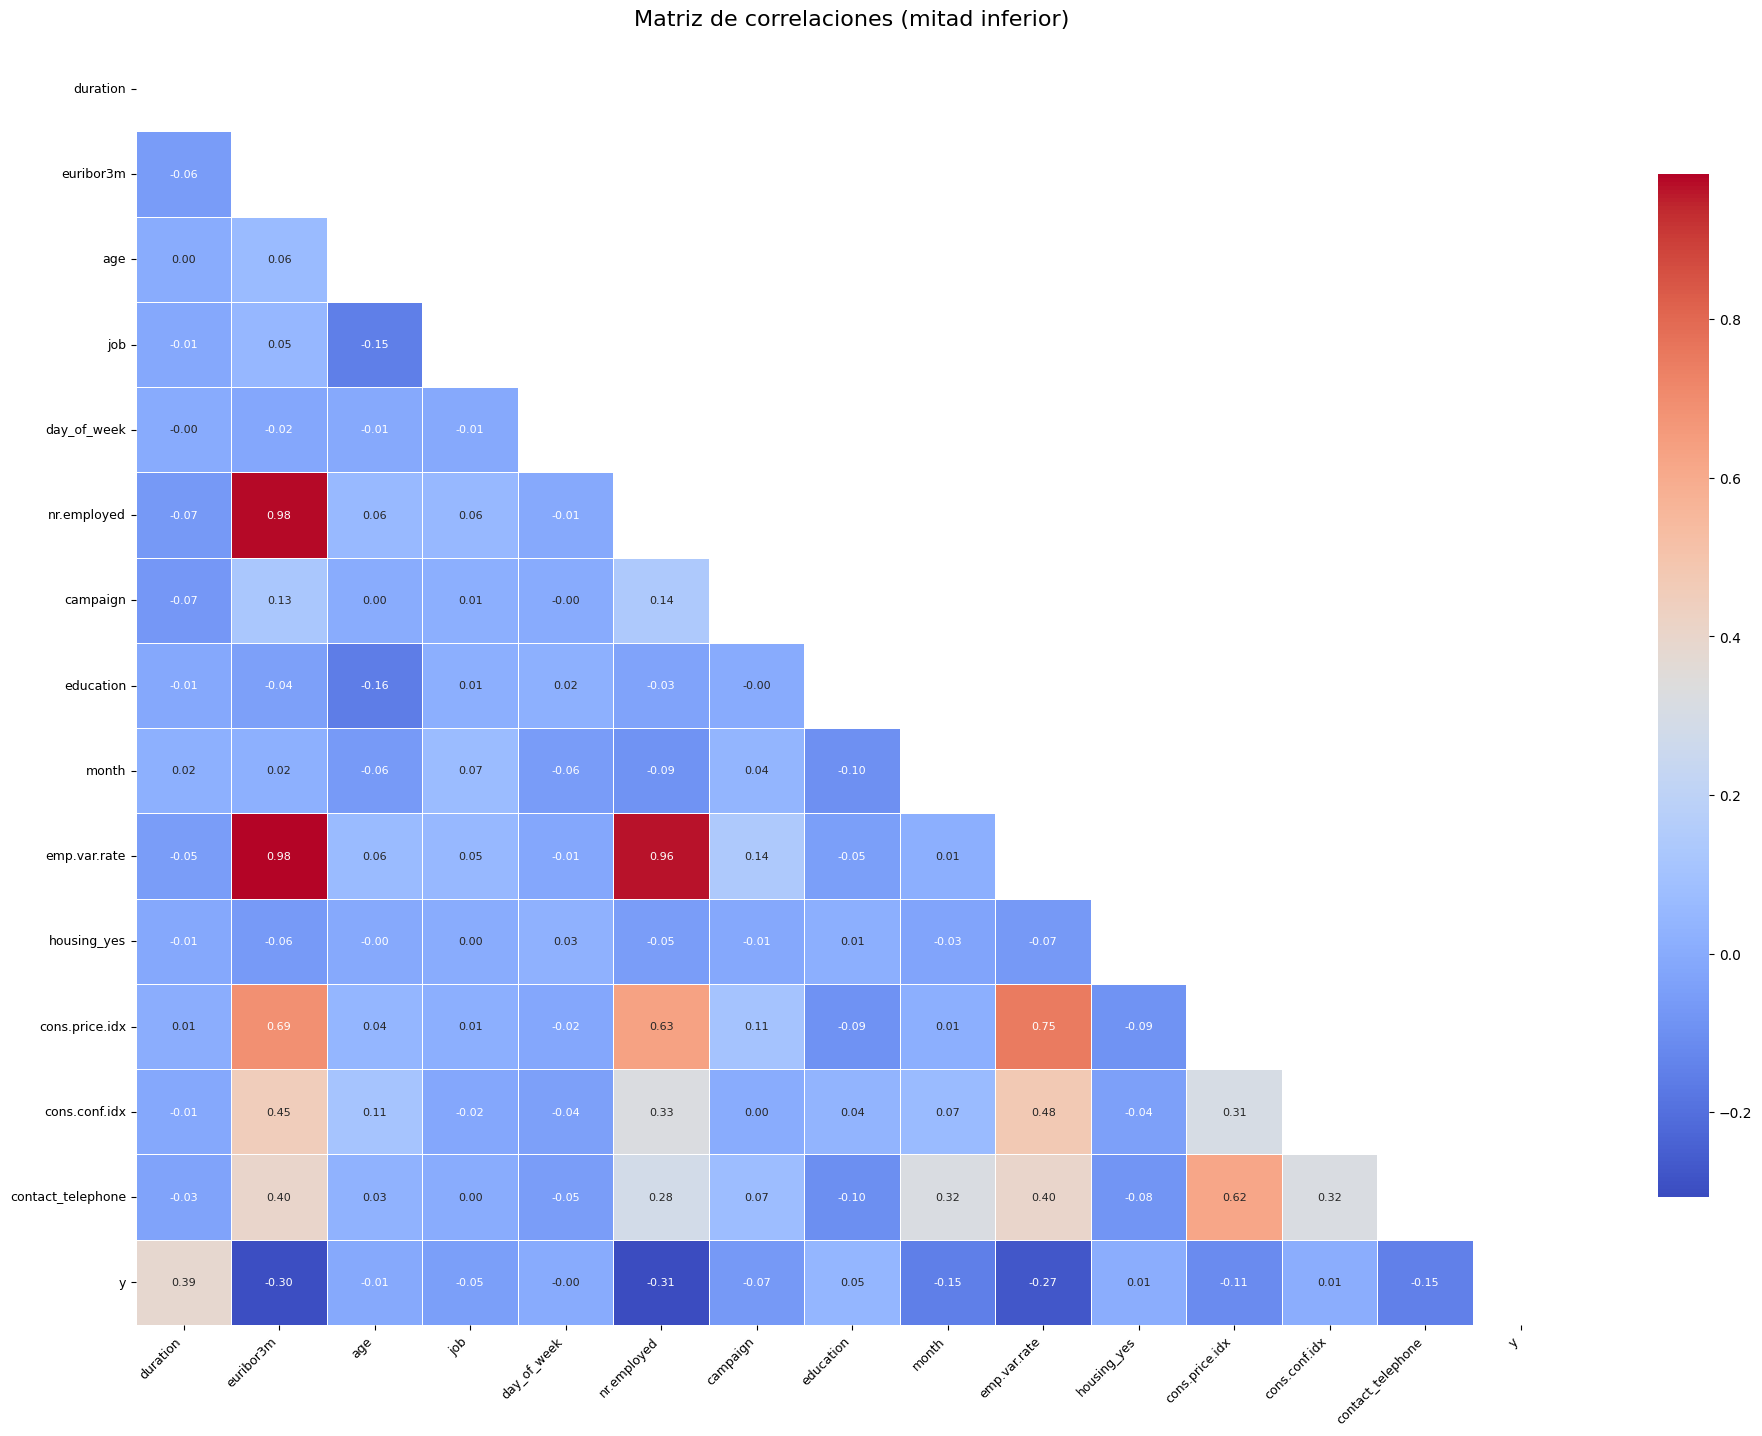

In [335]:
X_copy = X_train_final[features].copy()
X_copy['y'] = y_train
corr = X_copy.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(20, 15))
sns.heatmap(
    corr, mask=mask, cmap='coolwarm',
    annot=True, fmt=".2f", linewidths=.5,
    cbar_kws={"shrink": .8},
    annot_kws={"size": 8}
)
plt.title("Matriz de correlaciones (mitad inferior)", fontsize=16, pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout(pad=3.0)
plt.show()

### Cross_validation y seleccion final

In [336]:
# Versión 1: Realizar cross_validation con todas las características que son candidatas
cv_results1 = cross_val_score(RandomForestClassifier(random_state=42,n_jobs=-1), X_train_final[features], y_train, cv=3, scoring='accuracy')
cv_results1.mean()*1

np.float64(0.9081850937016722)

In [337]:
# Versión 2: Realizar cross_validation con  las características que son candidatas sin las que poseen mayor correlación
cv_results2 = cross_val_score(RandomForestClassifier(random_state=42,n_jobs=-1), X_train_final[features].drop(['nr.employed','cons.price.idx','emp.var.rate'],axis=1), y_train, cv=3, scoring='accuracy')
cv_results2.mean()*1

np.float64(0.9078478923056243)

Al realizar el Croos validation realizamos diferente convinaciones, eliminando aquellas caracteristicas que presentan mayor vif y que tienen mayor correlacion con euribor3m, por ende tomamos la version 2 aunque nos de menor accuracy ya que veo inbialbe tomar caracteristicas que tengan una correlacion mayor al 90% asi como del 69%

In [338]:
# Selecciona la caracteristicas con las que hemos determinado que vamos a proseguir el análisis
X_train_sel = X_train_final[features].drop(['nr.employed','cons.price.idx','emp.var.rate'],axis=1)
X_test_sel = X_test_final[features].drop(['nr.employed','cons.price.idx','emp.var.rate'],axis=1)

# Modelacion

## Regresión Logística.

In [339]:
# Entrenamos el modelo
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_sel, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [ ]:
y_pred = model.predict(X_test_sel)
accuracy_score(y_test, y_pred)

0.8941753525444512

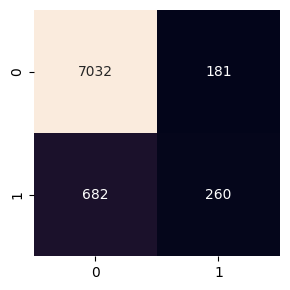

In [341]:
matrix_comfusion = confusion_matrix(y_test, y_pred)

# Dibujaremos esta matriz para hacerla más visual
cm_df = pd.DataFrame(matrix_comfusion)

plt.figure(figsize = (3, 3))
sns.heatmap(cm_df, annot=True, fmt="d", cbar=False)

plt.tight_layout()

plt.show()

## Optimizacion del modelo

### Busqueda extensiva de Hiperparametros

In [342]:
param_dist = {
    'C': np.logspace(-3, 3, 10),  # de 0.001 a 1000
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'],
    'class_weight': [None, 'balanced']
}

random_search = RandomizedSearchCV(
    model, param_distributions=param_dist,
    n_iter=20, cv=5, scoring='accuracy', n_jobs=-1, random_state=42
)
random_search.fit(X_train_sel, y_train)

print("Mejores parámetros:", random_search.best_params_)
print("Mejor score CV:", random_search.best_score_)

Mejores parámetros: {'solver': 'saga', 'penalty': 'l2', 'class_weight': None, 'C': np.float64(0.46415888336127775)}
Mejor score CV: 0.900797057020233


### Busqueda intensiva de hiperparamentros

In [348]:
model = LogisticRegression(max_iter=5000, solver='saga', penalty='l2')

# Grid de hiperparámetros centrado en C ~ 0.46
param_grid = {
    'C': np.linspace(0.1, 1.0, 10),  # 10 valores entre 0.1 y 1.0
    'class_weight': [None, 'balanced']  # probar con y sin balanceo
}

# GridSearchCV con 5-fold CV
grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train_sel, y_train)

print("Mejores parámetros:", grid.best_params_)
print("Mejor score CV:", grid.best_score_)

Mejores parámetros: {'C': np.float64(0.30000000000000004), 'class_weight': None}
Mejor score CV: 0.9008277130594727


In [356]:
y_pred1= grid.predict(X_test_sel)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy en test:", accuracy_score(y_test, y_pred1))

Accuracy en test: 0.8941753525444512


### Matrix de confusion y analisis 

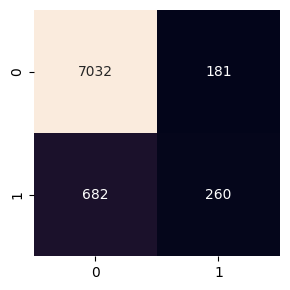

              precision    recall  f1-score   support

           0       0.91      0.97      0.94      7213
           1       0.59      0.28      0.38       942

    accuracy                           0.89      8155
   macro avg       0.75      0.63      0.66      8155
weighted avg       0.87      0.89      0.88      8155



In [353]:
matrix_comfusion = confusion_matrix(y_test, y_pred1)

# Dibujaremos esta matriz para hacerla más visual
cm_df = pd.DataFrame(matrix_comfusion)

plt.figure(figsize = (3, 3))
sns.heatmap(cm_df, annot=True, fmt="d", cbar=False)

plt.tight_layout()

plt.show()
print(classification_report(y_test, y_pred1))

De acuerdo a los resultados vemos que la busqueda intensiva de Hiperparametros nos dio el mismo resultado que el default, si bien el acurracy nos da alto, es engañoso ya que el modelo predice bastante bien la clase mayoritaria que es 0 (No contrata deposito a largo plazo), pero en la prediccion de la minoritaria es bastente pobre.

# Guardamos modelo

In [358]:
joblib.dump(grid, 'modelo_regresion_logistica.pkl')

['modelo_regresion_logistica.pkl']